## Import Libraries

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

src = "../data/MentalHealthSurvey_new.csv"

## Load Data

In [73]:
df = pd.read_csv(src)
df.head()

,gender,age,university,degree_level,degree_major,academic_year,cgpa,residential_status,campus_discrimination,sports_engagement,...,study_satisfaction,academic_workload,academic_pressure,financial_concerns,social_relationships,depression,anxiety,isolation,future_insecurity,stress_relief_activities
0,Female,17,PU,Undergraduate,Computer Science,1st year,3.5-4.0,On-Campus,No,No Sports,...,4,5,5,5,1,5,5,5,3,Sleep
1,Female,17,PU,Undergraduate,Computer Science,1st year,3.5-4.0,On-Campus,No,No Sports,...,4,4,4,5,3,4,4,5,2,Religious Activities
2,Male,17,PU,Undergraduate,Information Technology,1st year,0.0-0.0,Off-Campus,No,7+ times,...,3,5,5,1,3,4,4,4,5,Outdoor Activities
3,Male,18,PU,Undergraduate,Data Science,1st year,2.5-3.0,Off-Campus,No,4-6 times,...,4,3,4,4,4,3,4,4,2,"Sports and Fitness, Creative Outlets, Online E..."
4,Male,18,PU,Undergraduate,Data Science,1st year,3.5-4.0,Off-Campus,No,No Sports,...,5,3,1,1,3,1,2,2,1,Sleep


## Exploratory Data Analysis

In [74]:
# Check dataset if it needs cleaning or not
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   gender                    87 non-null     str  
 1   age                       87 non-null     int64
 2   university                87 non-null     str  
 3   degree_level              87 non-null     str  
 4   degree_major              87 non-null     str  
 5   academic_year             87 non-null     str  
 6   cgpa                      87 non-null     str  
 7   residential_status        87 non-null     str  
 8   campus_discrimination     87 non-null     str  
 9   sports_engagement         87 non-null     str  
 10  average_sleep             87 non-null     str  
 11  study_satisfaction        87 non-null     int64
 12  academic_workload         87 non-null     int64
 13  academic_pressure         87 non-null     int64
 14  financial_concerns        87 non-null     int64
 15  so

In [75]:
for col in df.columns:
    print(f"checking {col} column")
    print(df[col].unique())
    print("-" * 50)

checking gender column
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
checking age column
[17 18 19 20 21 22 23 26]
--------------------------------------------------
checking university column
<StringArray>
['PU', 'NUST', 'UOL', 'UET', 'FAST', 'COMSATS', 'UMT', 'VU', 'KUST']
Length: 9, dtype: str
--------------------------------------------------
checking degree_level column
<StringArray>
['Undergraduate', 'Postgraduate']
Length: 2, dtype: str
--------------------------------------------------
checking degree_major column
<StringArray>
[      'Computer Science', 'Information Technology',           'Data Science',
   'Software Engineering']
Length: 4, dtype: str
--------------------------------------------------
checking academic_year column
<StringArray>
['1st year', '2nd year', '3rd year', '4th year']
Length: 4, dtype: str
--------------------------------------------------
checking cgpa column
<StringArray>
['3.5-4.0', '0.0-0

In [76]:
# Check if the 0.0 cgpa is a valid value or not
anomalies = df[df["cgpa"] == '0.0-0.0']

print(len(anomalies))
print(anomalies["academic_year"].value_counts())

# -> small amount, and they are all in the 1st year, so we can drop them
df = df[df["cgpa"] != '0.0-0.0']
print(df.info()) # dataset after dropping invalid values

5
academic_year
1st year    5
Name: count, dtype: int64
<class 'pandas.DataFrame'>
Index: 82 entries, 0 to 86
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   gender                    82 non-null     str  
 1   age                       82 non-null     int64
 2   university                82 non-null     str  
 3   degree_level              82 non-null     str  
 4   degree_major              82 non-null     str  
 5   academic_year             82 non-null     str  
 6   cgpa                      82 non-null     str  
 7   residential_status        82 non-null     str  
 8   campus_discrimination     82 non-null     str  
 9   sports_engagement         82 non-null     str  
 10  average_sleep             82 non-null     str  
 11  study_satisfaction        82 non-null     int64
 12  academic_workload         82 non-null     int64
 13  academic_pressure         82 non-null     int64
 14  fina

In [77]:
# Splitting the stress_relief_activities column to each individual activity
activities = df["stress_relief_activities"].str.get_dummies(sep=", ")

df = pd.concat([df, activities], axis=1)
df = df.drop("stress_relief_activities", axis=1)

# renaming the activity columns to be more descriptive
activity_list = activities.columns.tolist()
new_activity_names = [f"activity_{activity.strip().lower().replace(' ', '_')}" for activity in activity_list]
activities.columns = new_activity_names

# update the main dataframe with the new activity column names
df = df.drop(activity_list, axis=1)  # drop old activity columns
df = pd.concat([df, activities], axis=1)  # add new activity columns

print(activities.columns)
df.head()

Index(['activity_creative_outlets', 'activity_nothing',
       'activity_online_entertainment', 'activity_outdoor_activities',
       'activity_religious_activities', 'activity_sleep',
       'activity_social_connections', 'activity_sports_and_fitness'],
      dtype='str')


,gender,age,university,degree_level,degree_major,academic_year,cgpa,residential_status,campus_discrimination,sports_engagement,...,isolation,future_insecurity,activity_creative_outlets,activity_nothing,activity_online_entertainment,activity_outdoor_activities,activity_religious_activities,activity_sleep,activity_social_connections,activity_sports_and_fitness
0,Female,17,PU,Undergraduate,Computer Science,1st year,3.5-4.0,On-Campus,No,No Sports,...,5,3,0,0,0,0,0,1,0,0
1,Female,17,PU,Undergraduate,Computer Science,1st year,3.5-4.0,On-Campus,No,No Sports,...,5,2,0,0,0,0,1,0,0,0
3,Male,18,PU,Undergraduate,Data Science,1st year,2.5-3.0,Off-Campus,No,4-6 times,...,4,2,1,0,1,1,0,0,0,1
4,Male,18,PU,Undergraduate,Data Science,1st year,3.5-4.0,Off-Campus,No,No Sports,...,2,1,0,0,0,0,0,1,0,0
5,Male,18,PU,Undergraduate,Data Science,1st year,1.5-2.0,On-Campus,No,No Sports,...,4,4,0,0,0,0,1,0,0,0


depression
5    20
4    18
3    18
1    13
2    13
Name: count, dtype: int64


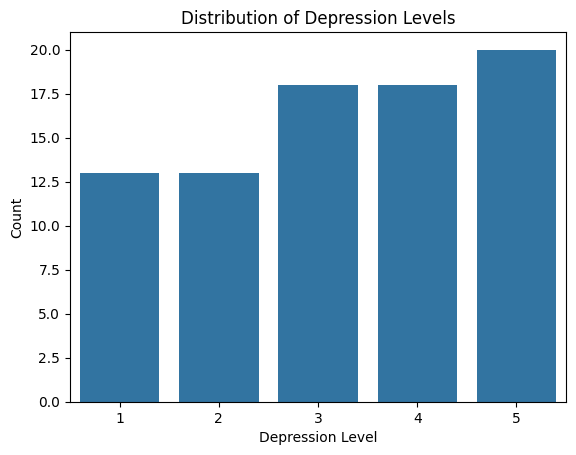

In [80]:
# Data visualization
# distribution of depression levels
print(df["depression"].value_counts())
sns.countplot(x="depression", data=df)
plt.title("Distribution of Depression Levels")
plt.xlabel("Depression Level")
plt.ylabel("Count")
plt.show()


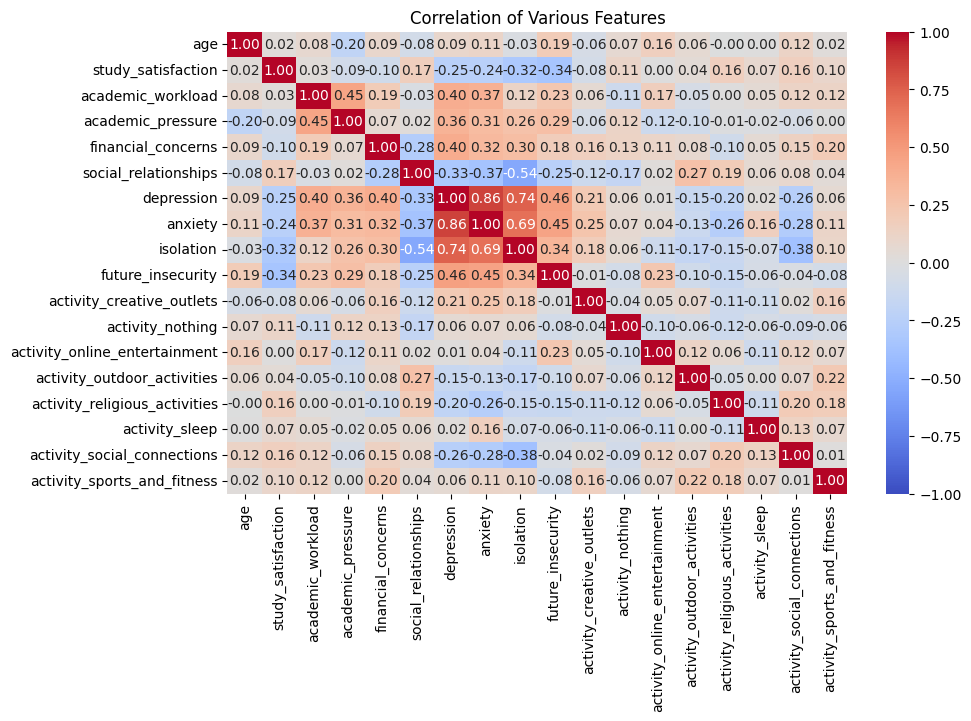

In [89]:
# splitting the dataset to each type features
numerical_features = df.select_dtypes(include=['int64', 'float64', 'int32'])

# selecting the depression feature
depression_corr = numerical_features.corr()[["depression"]].sort_values(by="depression", ascending=False)

# data visualization
plt.figure(figsize=(10, 6))
sns.heatmap(numerical_features.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation of Various Features")
plt.show()

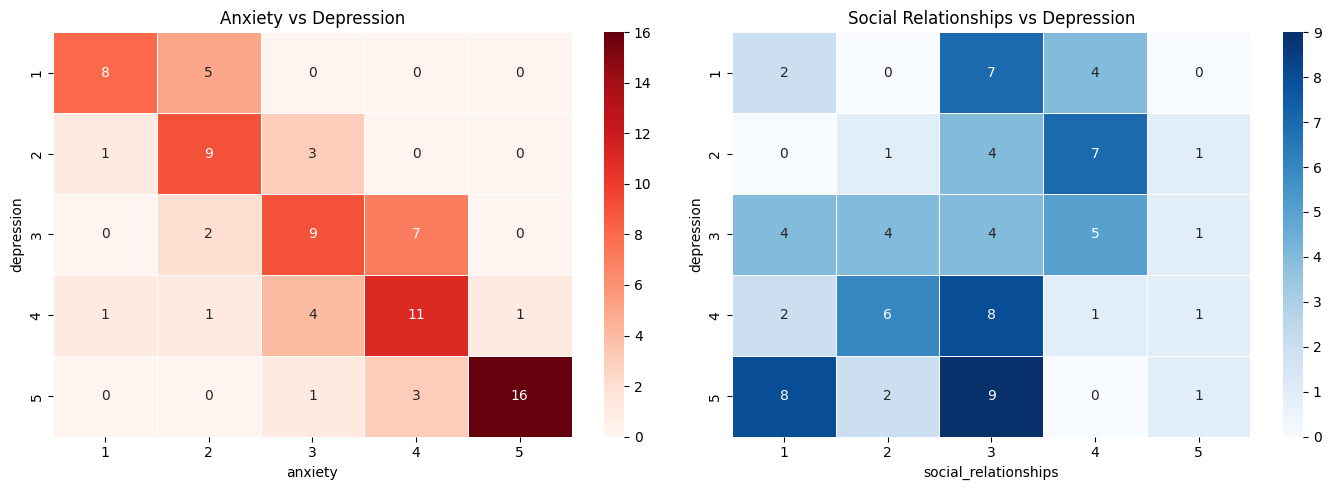

In [101]:
# barchart of the most correlated features with depression
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
anxiety_density_grid = pd.crosstab(df['depression'], df['anxiety'])
social_relationship_density_grid = pd.crosstab(df['depression'], df['social_relationships'])

sns.heatmap(anxiety_density_grid, annot=True, cmap='Reds', fmt='d', linewidths=0.5, ax=axes[0])
axes[0].set_title('Anxiety vs Depression')

sns.heatmap(social_relationship_density_grid, annot=True, cmap='Blues', fmt='d', linewidths=0.5, ax=axes[1])
axes[1].set_title('Social Relationships vs Depression')
plt.tight_layout()
plt.show()
